<a href="https://colab.research.google.com/github/snehasawant054-design/CSL701-CE-43_Machine-learning-lab/blob/main/Experiments/Experiment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Sneha Sawant

Batch : CE-3


Roll Number : CE-43



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Load dataset
data = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

print("\nFirst 5 rows:")
print(data.head())

Saving archive.zip to archive.zip
Dataset loaded successfully!
Dataset shape: (569, 32)

First 5 rows:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.te

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
print("Missing Values:")
print(data.isnull().sum())

print("\nSummary Statistics:")
print(data.describe())

print("\nFeature Dimensions:")
print(data.shape)

print("\nDiagnosis Class Distribution:")
print(data.iloc[:, -1].value_counts())

Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Summary Statistics:
       Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  \
count  569.000000     569.000000      569.000000        569.000000   
mean   285

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns
X = data.select_dtypes(include=["number"])

# Remove unnecessary ID column if present
X = X.drop(columns=["id", "Unnamed: 32", "Unnamed: 0"], errors="ignore")

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")
print("Scaled data shape:", X_scaled.shape)

Features scaled successfully!
Scaled data shape: (569, 30)


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
from scipy.spatial.distance import pdist, squareform
import networkx as nx

# Calculate pairwise Euclidean distances
distance_matrix = squareform(pdist(X_scaled, metric="euclidean"))

print("Distance Matrix Shape:", distance_matrix.shape)

# Create weighted complete graph
G = nx.from_numpy_array(distance_matrix)

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
from scipy.sparse.csgraph import minimum_spanning_tree

# Calculate MST
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert to NetworkX graph
MST = nx.from_scipy_sparse_array(mst_sparse)

print("Number of MST Nodes:", MST.number_of_nodes())
print("Number of MST Edges:", MST.number_of_edges())

print("\nMST Connections and Weights:")

for u, v, weight in MST.edges(data="weight"):
    print(u, "--", v, "Weight:", weight)

Number of MST Nodes: 569
Number of MST Edges: 568

MST Connections and Weights:
0 -- 81 Weight: 1.688589884751502
0 -- 108 Weight: 2.1714476618283567
1 -- 105 Weight: 1.6607267131218872
2 -- 70 Weight: 2.218949334515698
3 -- 170 Weight: 2.346213328330311
3 -- 222 Weight: 2.5415242027912224
4 -- 84 Weight: 2.166020221845041
4 -- 279 Weight: 1.8603236849319482
5 -- 125 Weight: 1.7658726578704034
5 -- 172 Weight: 2.0170999016357793
6 -- 336 Weight: 1.420405629997162
6 -- 393 Weight: 1.693333018082841
7 -- 140 Weight: 1.7729741603295777
8 -- 66 Weight: 1.510796194812844
9 -- 95 Weight: 1.672857536673303
9 -- 126 Weight: 1.5756451124670745
9 -- 192 Weight: 1.6263662682260864
10 -- 126 Weight: 1.7781363249984476
11 -- 140 Weight: 1.3252361905162215
11 -- 192 Weight: 1.839571379328235
12 -- 322 Weight: 1.995986497794778
13 -- 191 Weight: 3.197859615393217
13 -- 247 Weight: 3.245667964045753
14 -- 16 Weight: 2.7456517340185393
15 -- 103 Weight: 3.631454757883303
16 -- 24 Weight: 1.768358224488

# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Copy MST
MST_cluster = MST.copy()

# Find the largest edge
largest_edge = max(
    MST_cluster.edges(data=True),
    key=lambda x: x[2]["weight"]
)

print("Largest Edge:", largest_edge)

# Remove the largest edge
MST_cluster.remove_edge(
    largest_edge[0],
    largest_edge[1]
)

# Find connected components
components = list(nx.connected_components(MST_cluster))

# Create cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

print("\nNumber of Clusters:", len(components))
print("Cluster Labels:")
print(cluster_labels)

Largest Edge: (544, 553, {'weight': 12.299945385815649})

Number of Clusters: 2
Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0

# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

# Ground truth labels
true_labels = data.iloc[:, -1]

# Convert labels to numbers
true_labels = pd.factorize(true_labels)[0]

# Evaluation metrics
silhouette = silhouette_score(X_scaled, cluster_labels)

ari = adjusted_rand_score(true_labels, cluster_labels)

nmi = normalized_mutual_info_score(true_labels, cluster_labels)

print("Silhouette Score:", silhouette)
print("Adjusted Rand Index (ARI):", ari)
print("Normalized Mutual Information (NMI):", nmi)

Silhouette Score: 0.6606668813897673
Adjusted Rand Index (ARI): 0.0048283446965917305
Normalized Mutual Information (NMI): 0.010182219220269649


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

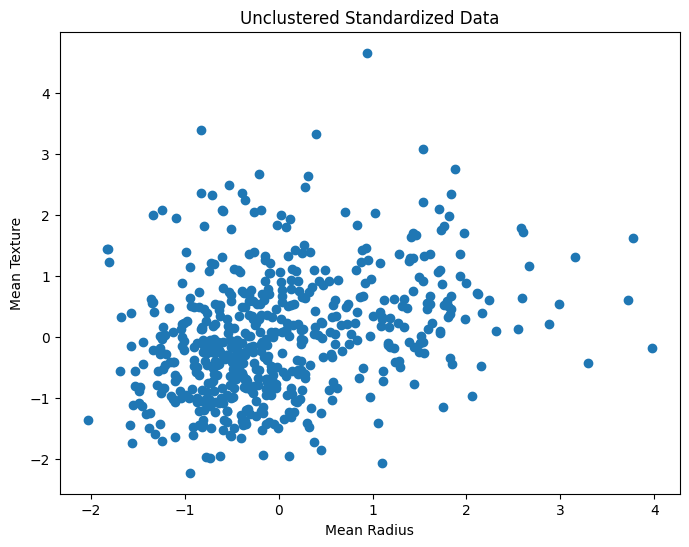

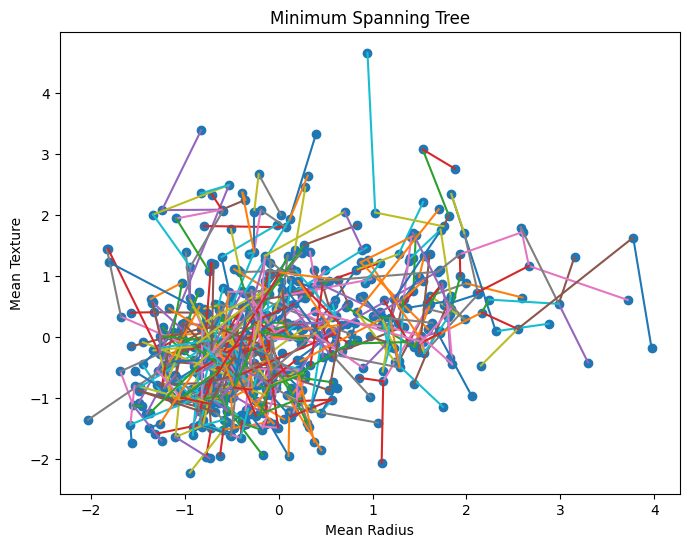

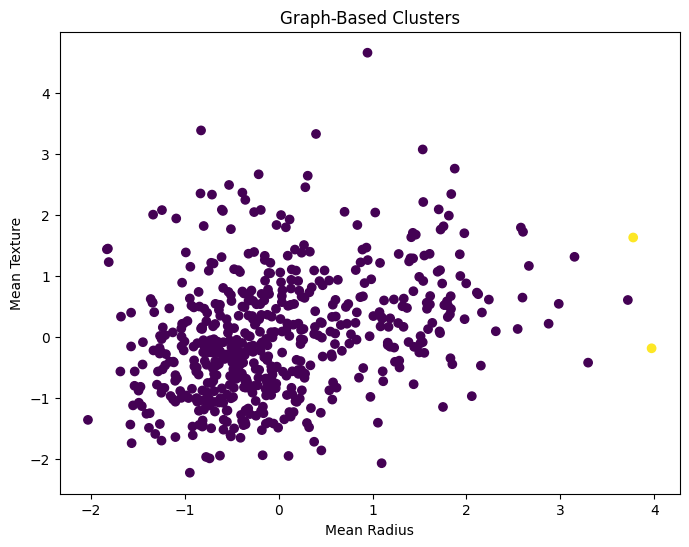

In [ ]:
# Select two features
radius_index = X.columns.get_loc("x.radius_mean")
texture_index = X.columns.get_loc("x.texture_mean")

x = X_scaled[:, radius_index]
y_plot = X_scaled[:, texture_index]

# Plot 1: Unclustered data
plt.figure(figsize=(8, 6))

plt.scatter(x, y_plot)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Unclustered Standardized Data")

plt.show()


# Plot 2: MST
plt.figure(figsize=(8, 6))

plt.scatter(x, y_plot)

for u, v in MST.edges():
    plt.plot(
        [x[u], x[v]],
        [y_plot[u], y_plot[v]]
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Minimum Spanning Tree")

plt.show()


# Plot 3: Final Clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y_plot,
    c=cluster_labels
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Graph-Based Clusters")

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.